# Word Embeddings with Gensim

## Setup

In [3]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install nltk
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
import gensim.downloader as api
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import nltk
from nltk.tokenize import word_tokenize
import random

# Download necessary NLTK data
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Load a pre-trained GloVe model

In [5]:
model = api.load('glove-wiki-gigaword-100')  # 100-dimensional GloVe vectors trained on Wikipedia

print(f"Model loaded with {len(model.key_to_index)} word vectors!")

Model loaded with 400000 word vectors!


## Explore the vocabulary

Get some random words from the vocabulary:

In [6]:
random_words = random.sample(list(model.key_to_index.keys()), 10)
print("\nSample words from vocabulary:")
print(random_words)


Sample words from vocabulary:
['thành', 'berdych', 'yū', 'dhubri', '25-person', '1,102', 'buffington', 'co-recipient', 'single-frequency', 'papadopoulou']


Check if specific words exist in the vocabulary:

In [7]:
words_to_check = ['computer', 'artificial', 'intelligence', 'python', 'nonexistentword123']
for word in words_to_check:
    print(f"Is '{word}' in vocabulary? {word in model}")


Is 'computer' in vocabulary? True
Is 'artificial' in vocabulary? True
Is 'intelligence' in vocabulary? True
Is 'python' in vocabulary? True
Is 'nonexistentword123' in vocabulary? False


## Examine word vectors

In [8]:
# Get the vector for a specific word
word = 'computer'
vector = model[word]
print(f"\nVector for '{word}' (first 10 dimensions):")
print(vector[:10])
print(f"Vector shape: {vector.shape}")


Vector for 'computer' (first 10 dimensions):
[-0.16298   0.30141   0.57978   0.066548  0.45835  -0.15329   0.43258
 -0.89215   0.57747   0.36375 ]
Vector shape: (100,)


## Find similar words

In [9]:
similar_words = model.most_similar('computer', topn=10)
print(f"\nWords most similar to 'computer':")
for word, score in similar_words:
    print(f"{word}: {score:.4f}")


Words most similar to 'computer':
computers: 0.8752
software: 0.8373
technology: 0.7642
pc: 0.7366
hardware: 0.7290
internet: 0.7287
desktop: 0.7234
electronic: 0.7222
systems: 0.7198
computing: 0.7142


## Vector arithmetic with word embeddings

Let's compute the classic example: king - man + woman = queen

In [10]:
result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=5)
print("\nVector arithmetic (king - man + woman):")
for word, score in result:
    print(f"{word}: {score:.4f}")


Vector arithmetic (king - man + woman):
queen: 0.7699
monarch: 0.6843
throne: 0.6756
daughter: 0.6595
princess: 0.6521


 Try another example: paris - france + italy = rome

In [11]:
result = model.most_similar(positive=['paris', 'italy'], negative=['france'], topn=5)
print("\nVector arithmetic (paris - france + italy):")
for word, score in result:
    print(f"{word}: {score:.4f}")


Vector arithmetic (paris - france + italy):
rome: 0.8190
milan: 0.7376
naples: 0.7118
venice: 0.7015
turin: 0.6995


## Find odd one out

Which word doesn't belong in this list?

In [12]:
words = ['breakfast', 'lunch', 'dinner', 'dog', 'supper']
try:
    odd_one = model.doesnt_match(words)
    print(f"\nOdd one out among {words}: {odd_one}")
except KeyError as e:
    print(f"Couldn't find odd one out because: {e}")


Odd one out among ['breakfast', 'lunch', 'dinner', 'dog', 'supper']: dog


## Measuring word similarity

Calculate similarity between pairs of words.

In [13]:
word_pairs = [
    ('car', 'automobile'),
    ('computer', 'keyboard'),
    ('computer', 'banana'),
    ('cat', 'dog'),
    ('king', 'queen')
]

print("\nWord similarities:")
for word1, word2 in word_pairs:
    try:
        similarity = model.similarity(word1, word2)
        print(f"Similarity between '{word1}' and '{word2}': {similarity:.4f}")
    except KeyError as e:
        print(f"Couldn't calculate similarity between '{word1}' and '{word2}' because: {e}")


Word similarities:
Similarity between 'car' and 'automobile': 0.6832
Similarity between 'computer' and 'keyboard': 0.5418
Similarity between 'computer' and 'banana': 0.1213
Similarity between 'cat' and 'dog': 0.8798
Similarity between 'king' and 'queen': 0.7508


## Visualize word embeddings

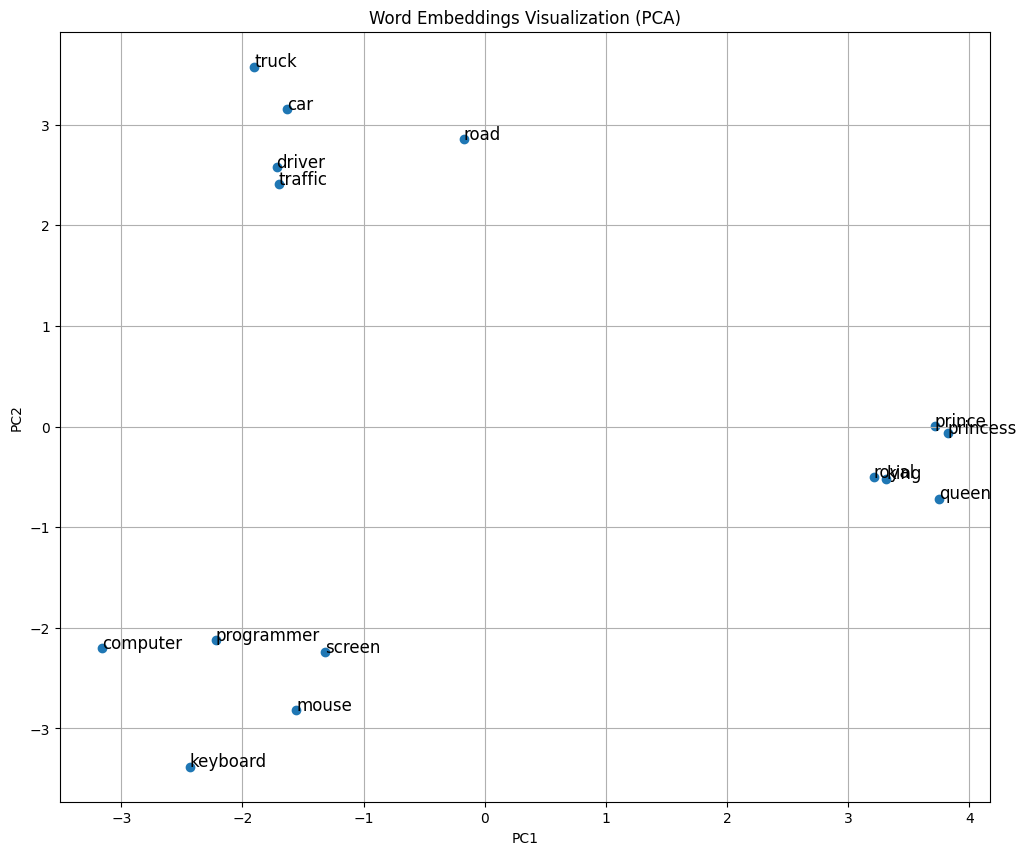

In [14]:
# Select some words to visualize
words_to_viz = ['computer', 'keyboard', 'mouse', 'screen', 'programmer', 
                'car', 'truck', 'road', 'driver', 'traffic',
                'king', 'queen', 'prince', 'princess', 'royal']

# Filter out words not in vocabulary
words_to_viz = [word for word in words_to_viz if word in model]

# Get vectors for these words
word_vectors = [model[word] for word in words_to_viz]

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

# Create a DataFrame for plotting
df = pd.DataFrame(result, columns=['x', 'y'])
df['word'] = words_to_viz

# Plot
plt.figure(figsize=(12, 10))
plt.scatter(df['x'], df['y'])

# Add labels to each point
for i, txt in enumerate(df['word']):
    plt.annotate(txt, (df['x'][i], df['y'][i]), fontsize=12)

plt.title('Word Embeddings Visualization (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

## Alternative visualization with t-SNE

t-SNE often gives better visualizations for high-dimensional data.

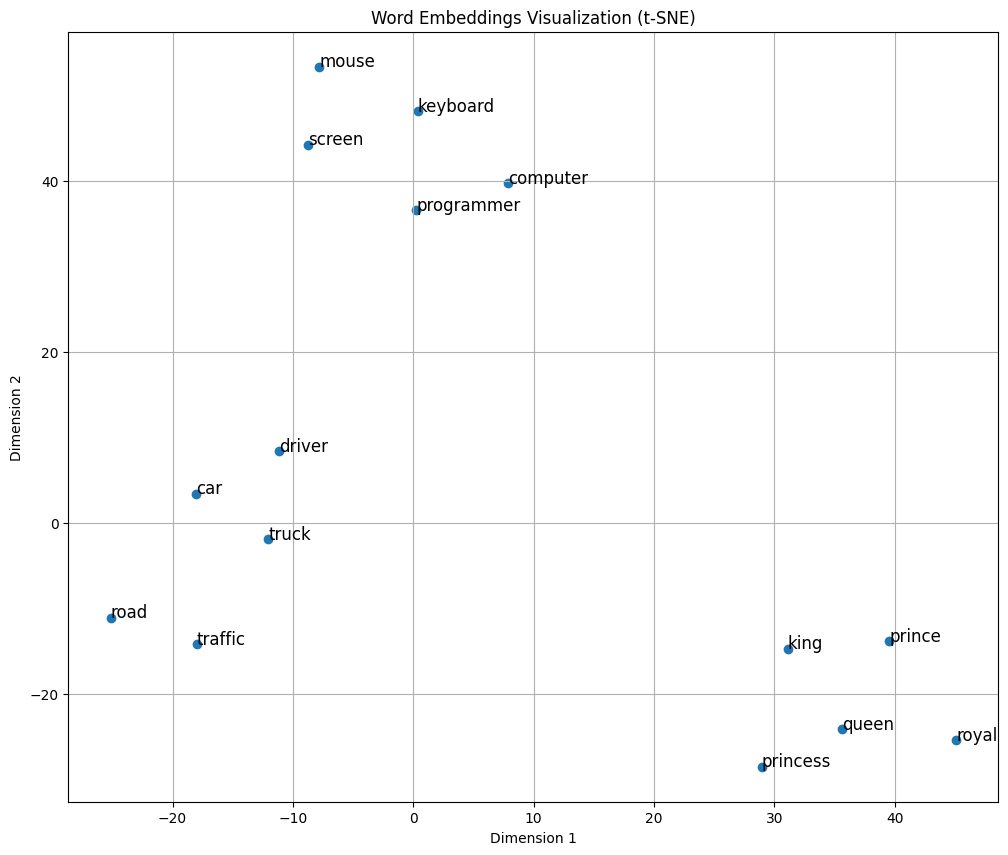

In [15]:
word_vectors_array = np.array(word_vectors)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
result = tsne.fit_transform(word_vectors_array)

# Create a DataFrame for plotting
df = pd.DataFrame(result, columns=['x', 'y'])
df['word'] = words_to_viz

# Plot
plt.figure(figsize=(12, 10))
plt.scatter(df['x'], df['y'])

# Add labels to each point
for i, txt in enumerate(df['word']):
    plt.annotate(txt, (df['x'][i], df['y'][i]), fontsize=12)

plt.title('Word Embeddings Visualization (t-SNE)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()

## Exercise

Create a simple word relationship application, e.g., Input two words and find words that are related to both

In [16]:
def find_related_words(word1, word2, topn=10):
    word1 = word1.strip().lower()
    word2 = word2.strip().lower()

    missing = [w for w in [word1, word2] if w not in model]
    if missing:
        print(f"Word(s) not found in vocabulary: {', '.join(missing)}")
        return []

    related = model.most_similar(positive=[word1, word2], topn=topn)
    print(f"\nWords related to both '{word1}' and '{word2}':")
    for idx, (word, score) in enumerate(related, start=1):
        print(f"{idx:2d}. {word:15s} {score:.4f}")
    return related

# Change these two words to test new combinations
word_a = "computer"
word_b = "science"

find_related_words(word_a, word_b, topn=10)


Words related to both 'computer' and 'science':
 1. technology      0.8190
 2. computers       0.7273
 3. research        0.7245
 4. engineering     0.7196
 5. computing       0.7166
 6. physics         0.7081
 7. software        0.6996
 8. mathematics     0.6910
 9. sciences        0.6906
10. learning        0.6865


[('technology', 0.8189904093742371),
 ('computers', 0.7273058891296387),
 ('research', 0.7245298624038696),
 ('engineering', 0.7195667624473572),
 ('computing', 0.7166299223899841),
 ('physics', 0.7080919742584229),
 ('software', 0.6996390223503113),
 ('mathematics', 0.6909719705581665),
 ('sciences', 0.6906241774559021),
 ('learning', 0.686476469039917)]

Per trobar paraules relacionades el més fàcil és sumar les dues paraules i mirar quines estan a prop del vector resultant